In [1]:
# ==========================================================
# Loan Approval Prediction
# Notebook 05 - Model Building
# ==========================================================
import sys

print(sys.executable)
%pip install xgboost

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

/opt/anaconda3/bin/python
Note: you may need to restart the kernel to use updated packages.


In [2]:
from xgboost import XGBClassifier

print("XGBoost Imported Successfully")

XGBoost Imported Successfully


In [3]:
# ==========================================================
# Loan Approval Prediction
# Notebook 05 - Model Building
# ==========================================================

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Feature Scaling
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

In [4]:
import os

path = "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed/loan_feature_engineered.csv"

print(os.path.exists(path))

True


In [9]:
import os

folder = "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed"

print(os.listdir(folder))

['loan_feature_engineered.csv', 'loan_clean.csv', 'LoanApprovalPrediction.csv']


In [11]:
loan_df = pd.read_csv(
    "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed/loan_feature_engineered.csv"
)

loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log,LoanAmount_Log
0,1,0,0.0,0,0,0.095951,-0.552892,-0.213425,0.274031,1.0,2,1,-0.172910,-0.135268,-0.229622,-0.249273,0.539391,0.022901,-0.013951
1,1,1,1.0,0,0,-0.122234,-0.041852,-0.201115,0.274031,1.0,0,0,-0.133976,-0.094839,-0.224180,-0.329632,0.152174,0.098340,0.001994
2,1,1,0.0,0,1,-0.395052,-0.552892,-0.964324,0.274031,1.0,2,1,-0.631266,-0.151129,-0.561597,-0.216268,-0.520462,-1.219365,-1.340341
3,1,1,0.0,1,0,-0.466919,0.246201,-0.299594,0.274031,1.0,2,1,-0.318992,-0.264151,-0.267718,0.046793,-0.758008,-0.291011,-0.129186
4,1,0,0.0,0,0,0.121975,-0.552892,-0.041088,0.274031,1.0,2,1,-0.148616,-0.227753,-0.153431,-0.043700,0.579856,0.070330,0.198728


In [13]:
loan_df = pd.read_csv(
"/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/data/processed/loan_feature_engineered.csv"
)

loan_df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log,LoanAmount_Log
0,1,0,0.0,0,0,0.095951,-0.552892,-0.213425,0.274031,1.0,2,1,-0.172910,-0.135268,-0.229622,-0.249273,0.539391,0.022901,-0.013951
1,1,1,1.0,0,0,-0.122234,-0.041852,-0.201115,0.274031,1.0,0,0,-0.133976,-0.094839,-0.224180,-0.329632,0.152174,0.098340,0.001994
2,1,1,0.0,0,1,-0.395052,-0.552892,-0.964324,0.274031,1.0,2,1,-0.631266,-0.151129,-0.561597,-0.216268,-0.520462,-1.219365,-1.340341
3,1,1,0.0,1,0,-0.466919,0.246201,-0.299594,0.274031,1.0,2,1,-0.318992,-0.264151,-0.267718,0.046793,-0.758008,-0.291011,-0.129186
4,1,0,0.0,0,0,0.121975,-0.552892,-0.041088,0.274031,1.0,2,1,-0.148616,-0.227753,-0.153431,-0.043700,0.579856,0.070330,0.198728


In [15]:
loan_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 598 entries, 0 to 597
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               598 non-null    int64  
 1   Married              598 non-null    int64  
 2   Dependents           598 non-null    float64
 3   Education            598 non-null    int64  
 4   Self_Employed        598 non-null    int64  
 5   ApplicantIncome      598 non-null    float64
 6   CoapplicantIncome    598 non-null    float64
 7   LoanAmount           598 non-null    float64
 8   Loan_Amount_Term     598 non-null    float64
 9   Credit_History       598 non-null    float64
 10  Property_Area        598 non-null    int64  
 11  Loan_Status          598 non-null    int64  
 12  TotalIncome          598 non-null    float64
 13  Income_Loan_Ratio    598 non-null    float64
 14  EMI                  598 non-null    float64
 15  LoanIncomeRatio      598 non-null    flo

In [17]:
X = loan_df.drop("Loan_Status", axis=1)

y = loan_df["Loan_Status"]

In [19]:
X_train, X_test, Y_train, Y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [21]:
print("X_train :", X_train.shape)

print("X_test :", X_test.shape)

print("Y_train :", Y_train.shape)

print("Y_test :", Y_test.shape)

X_train : (478, 18)
X_test : (120, 18)
Y_train : (478,)
Y_test : (120,)


In [23]:
num_cols = [

"ApplicantIncome",

"CoapplicantIncome",

"LoanAmount",

"Loan_Amount_Term",

"TotalIncome",

"Income_Loan_Ratio",

"EMI",

"LoanIncomeRatio",

"ApplicantIncome_Log",

"LoanAmount_Log",

"TotalIncome_Log"

]

In [25]:
scaler = StandardScaler()

In [27]:
X_train[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

In [29]:
X_test[num_cols] = scaler.transform(
    X_test[num_cols]
)

In [31]:
X_train.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,TotalIncome,Income_Loan_Ratio,EMI,LoanIncomeRatio,ApplicantIncome_Log,TotalIncome_Log,LoanAmount_Log
27,1,0,0.0,1,0,-0.641139,-0.579006,-1.315993,0.267865,1.0,2,-0.850035,-0.253846,-0.700531,0.014127,-1.650434,-2.552517,-2.747331
443,1,1,0.0,0,0,-0.243197,0.058500,0.017671,0.267865,0.0,0,-0.207906,-0.342766,-0.120843,0.234062,-0.107403,-0.047789,0.273812
127,1,0,0.0,0,1,2.332150,-0.579006,5.878772,2.153572,1.0,2,1.986301,-0.548328,1.600423,0.909258,2.391801,2.267182,3.381237
400,1,1,1.0,0,0,0.447881,-0.579006,0.052767,-0.674989,0.0,1,0.188824,0.134110,0.048995,-0.655885,1.031264,0.644965,0.315733
279,1,0,0.0,0,0,-0.368646,0.544079,-0.684258,0.267865,1.0,0,-0.127621,0.573464,-0.425942,-1.103846,-0.449512,0.115187,-0.807584


In [33]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(probability=True),

    "Naive Bayes":
    GaussianNB(),

    "Decision Tree":
    DecisionTreeClassifier(random_state=42),

    "Random Forest":
    RandomForestClassifier(random_state=42),

    "XGBoost":
    XGBClassifier(

        random_state=42,

        eval_metric="logloss"

    )

}

In [35]:
for name, model in models.items():

    model.fit(

        X_train,

        Y_train

    )

print("All Models Trained Successfully")

All Models Trained Successfully


In [37]:
len(models)

7

In [39]:
results = []

In [41]:
for name, model in models.items():

    # Training Predictions
    train_pred = model.predict(X_train)

    # Testing Predictions
    test_pred = model.predict(X_test)

    # Accuracy
    train_accuracy = accuracy_score(Y_train, train_pred)
    test_accuracy = accuracy_score(Y_test, test_pred)

    # Precision
    precision = precision_score(Y_test, test_pred)

    # Recall
    recall = recall_score(Y_test, test_pred)

    # F1 Score
    f1 = f1_score(Y_test, test_pred)

    # ROC-AUC
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    roc = roc_auc_score(Y_test, y_prob)

    results.append([
        name,
        train_accuracy,
        test_accuracy,
        precision,
        recall,
        f1,
        roc
    ])

In [43]:
results_df = pd.DataFrame(
    results,
    columns=[
        "Model",
        "Train Accuracy",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ]
)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.811715,0.808333,0.792079,0.975610,0.874317,0.799101
1,KNN,0.801255,0.733333,0.740385,0.939024,0.827957,0.607349
2,SVM,0.826360,0.800000,0.784314,0.975610,0.869565,0.794929
3,Naive Bayes,0.805439,0.825000,0.808081,0.975610,0.883978,0.785302
4,Decision Tree,1.000000,0.733333,0.784091,0.841463,0.811765,0.670732
5,Random Forest,1.000000,0.808333,0.804124,0.951220,0.871508,0.782253
6,XGBoost,1.000000,0.808333,0.804124,0.951220,0.871508,0.801669


In [45]:
results_df = results_df.round(4)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8117,0.8083,0.7921,0.9756,0.8743,0.7991
1,KNN,0.8013,0.7333,0.7404,0.9390,0.8280,0.6073
2,SVM,0.8264,0.8000,0.7843,0.9756,0.8696,0.7949
3,Naive Bayes,0.8054,0.8250,0.8081,0.9756,0.8840,0.7853
4,Decision Tree,1.0000,0.7333,0.7841,0.8415,0.8118,0.6707
5,Random Forest,1.0000,0.8083,0.8041,0.9512,0.8715,0.7823
6,XGBoost,1.0000,0.8083,0.8041,0.9512,0.8715,0.8017


In [47]:
results_df.sort_values(
    by="Test Accuracy",
    ascending=False
)

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC
3,Naive Bayes,0.8054,0.8250,0.8081,0.9756,0.8840,0.7853
0,Logistic Regression,0.8117,0.8083,0.7921,0.9756,0.8743,0.7991
5,Random Forest,1.0000,0.8083,0.8041,0.9512,0.8715,0.7823
6,XGBoost,1.0000,0.8083,0.8041,0.9512,0.8715,0.8017
2,SVM,0.8264,0.8000,0.7843,0.9756,0.8696,0.7949
1,KNN,0.8013,0.7333,0.7404,0.9390,0.8280,0.6073
4,Decision Tree,1.0000,0.7333,0.7841,0.8415,0.8118,0.6707


In [49]:
results_df.to_csv(
"/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/reports/model_comparison.csv",
index=False
)

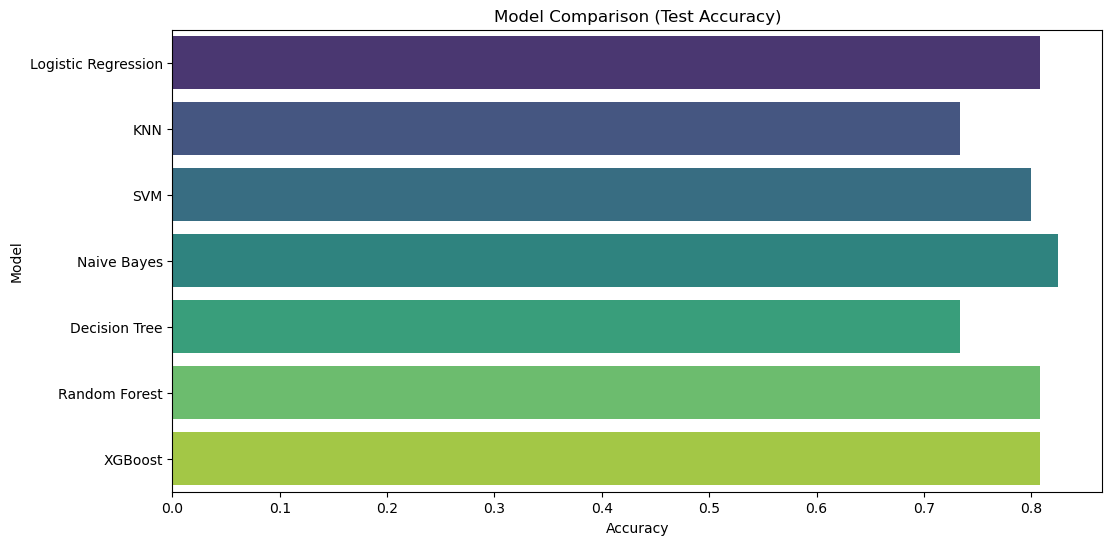

In [51]:
plt.figure(figsize=(12,6))

sns.barplot(
    x="Test Accuracy",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Model Comparison (Test Accuracy)")
plt.xlabel("Accuracy")
plt.ylabel("Model")

plt.show()

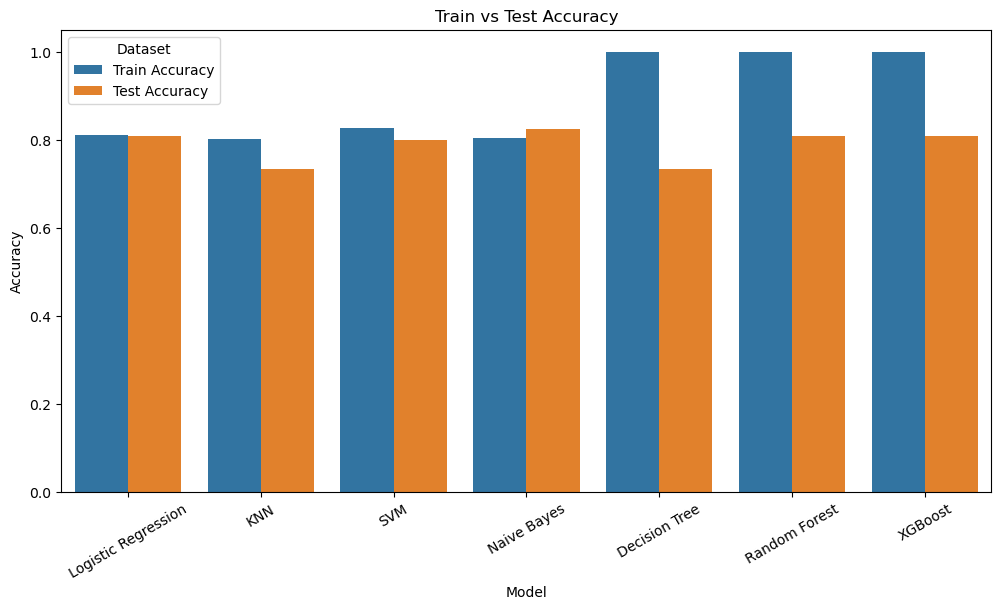

In [53]:
comparison = results_df.melt(
    id_vars="Model",
    value_vars=["Train Accuracy","Test Accuracy"],
    var_name="Dataset",
    value_name="Accuracy"
)

plt.figure(figsize=(12,6))

sns.barplot(
    x="Model",
    y="Accuracy",
    hue="Dataset",
    data=comparison
)

plt.xticks(rotation=30)

plt.title("Train vs Test Accuracy")

plt.show()

In [55]:
results_df["Difference"] = (
    results_df["Train Accuracy"] -
    results_df["Test Accuracy"]
)

results_df

,Model,Train Accuracy,Test Accuracy,Precision,Recall,F1 Score,ROC-AUC,Difference
0,Logistic Regression,0.8117,0.8083,0.7921,0.9756,0.8743,0.7991,0.0034
1,KNN,0.8013,0.7333,0.7404,0.9390,0.8280,0.6073,0.0680
2,SVM,0.8264,0.8000,0.7843,0.9756,0.8696,0.7949,0.0264
3,Naive Bayes,0.8054,0.8250,0.8081,0.9756,0.8840,0.7853,-0.0196
4,Decision Tree,1.0000,0.7333,0.7841,0.8415,0.8118,0.6707,0.2667
5,Random Forest,1.0000,0.8083,0.8041,0.9512,0.8715,0.7823,0.1917
6,XGBoost,1.0000,0.8083,0.8041,0.9512,0.8715,0.8017,0.1917


In [57]:
best_model = results_df.sort_values(
    by="Test Accuracy",
    ascending=False
).iloc[0]

print(best_model)

Model             Naive Bayes
Train Accuracy         0.8054
Test Accuracy           0.825
Precision              0.8081
Recall                 0.9756
F1 Score                0.884
ROC-AUC                0.7853
Difference            -0.0196
Name: 3, dtype: object


In [59]:
best_model_name = best_model["Model"]

print("Best Model:", best_model_name)

Best Model: Naive Bayes


In [61]:
best_model_object = models[best_model_name]

best_model_object

GaussianNB()

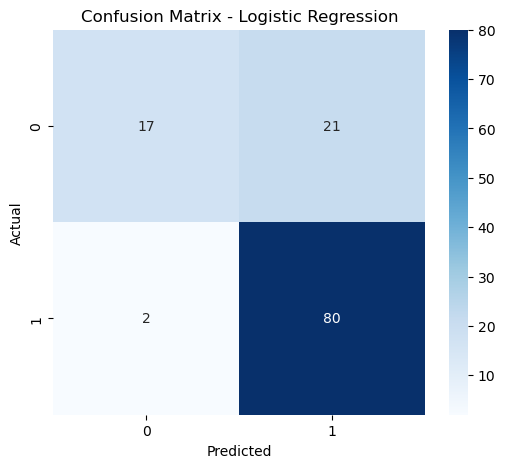

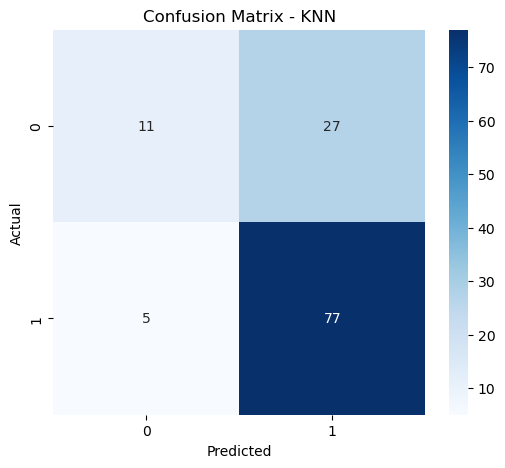

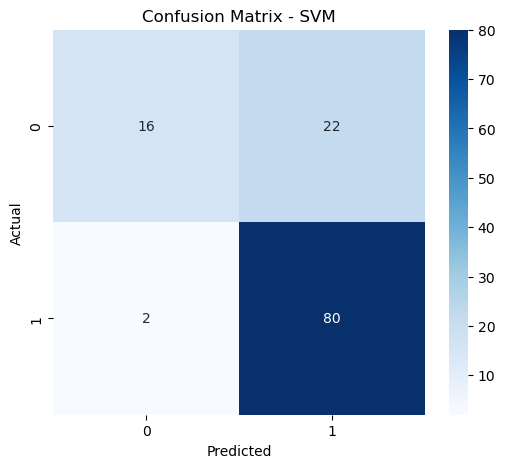

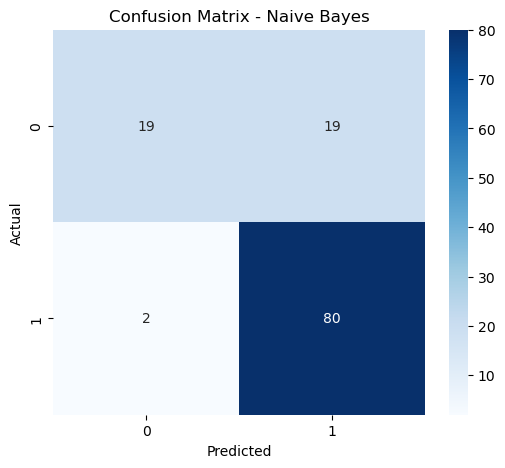

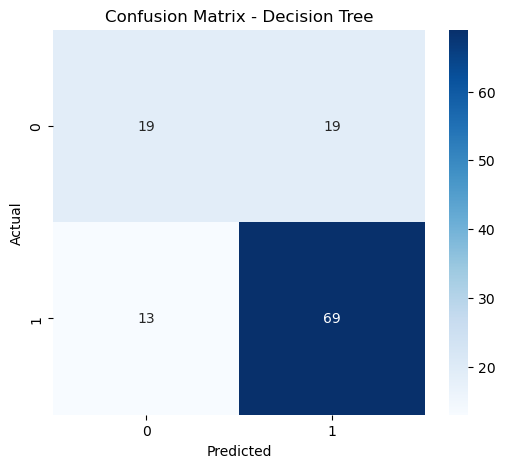

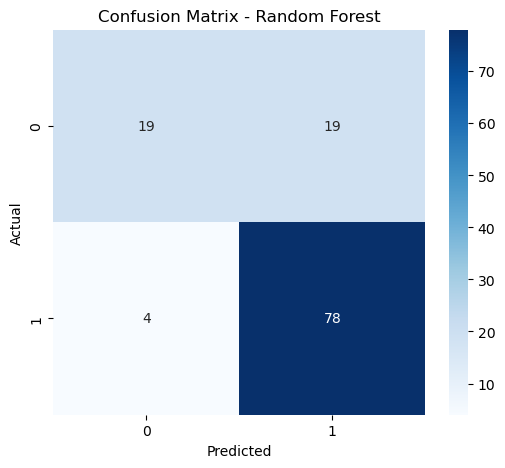

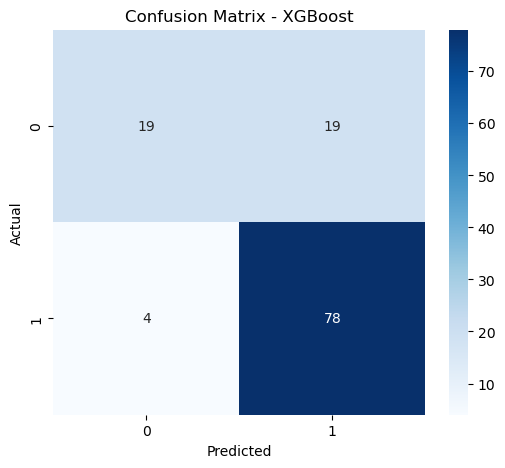

In [63]:
from sklearn.metrics import ConfusionMatrixDisplay

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(Y_test, y_pred)

    plt.figure(figsize=(6,5))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

In [65]:
for name, model in models.items():

    print("="*70)
    print(f"{name}")
    print("="*70)

    y_pred = model.predict(X_test)

    print(classification_report(Y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.89      0.45      0.60        38
           1       0.79      0.98      0.87        82

    accuracy                           0.81       120
   macro avg       0.84      0.71      0.74       120
weighted avg       0.82      0.81      0.79       120

KNN
              precision    recall  f1-score   support

           0       0.69      0.29      0.41        38
           1       0.74      0.94      0.83        82

    accuracy                           0.73       120
   macro avg       0.71      0.61      0.62       120
weighted avg       0.72      0.73      0.69       120

SVM
              precision    recall  f1-score   support

           0       0.89      0.42      0.57        38
           1       0.78      0.98      0.87        82

    accuracy                           0.80       120
   macro avg       0.84      0.70      0.72       120
weighted avg       0.82      0.80      0.78   

In [67]:
from sklearn.metrics import roc_curve

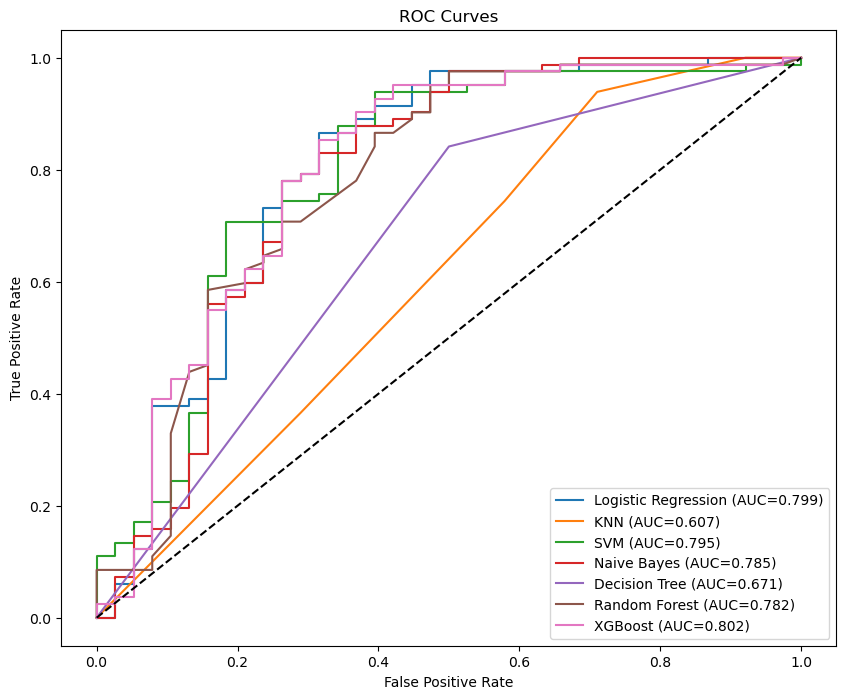

In [69]:
plt.figure(figsize=(10,8))

for name, model in models.items():

    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:,1]
    else:
        y_prob = model.decision_function(X_test)

    fpr, tpr, _ = roc_curve(Y_test, y_prob)

    auc = roc_auc_score(Y_test, y_prob)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC={auc:.3f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curves")

plt.legend()

plt.show()

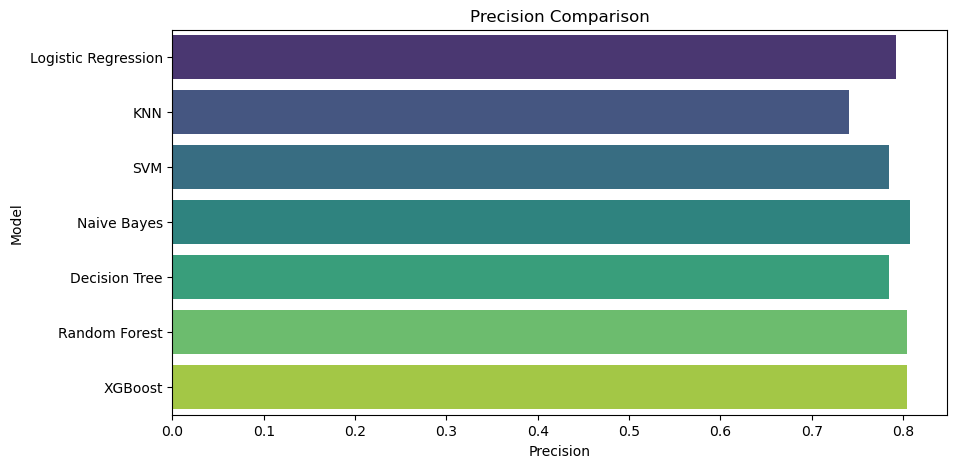

In [71]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Precision",
    y="Model",
    data=results_df,
    palette="viridis"
)

plt.title("Precision Comparison")

plt.show()

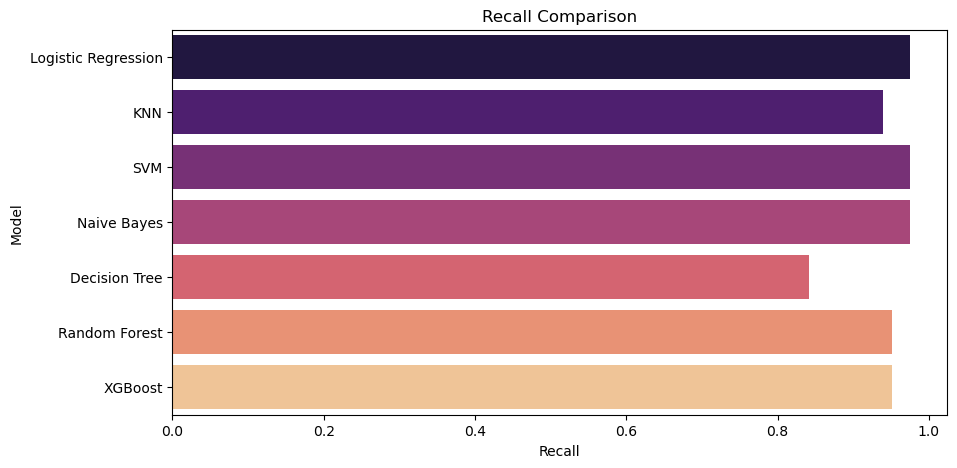

In [73]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="Recall",
    y="Model",
    data=results_df,
    palette="magma"
)

plt.title("Recall Comparison")

plt.show()

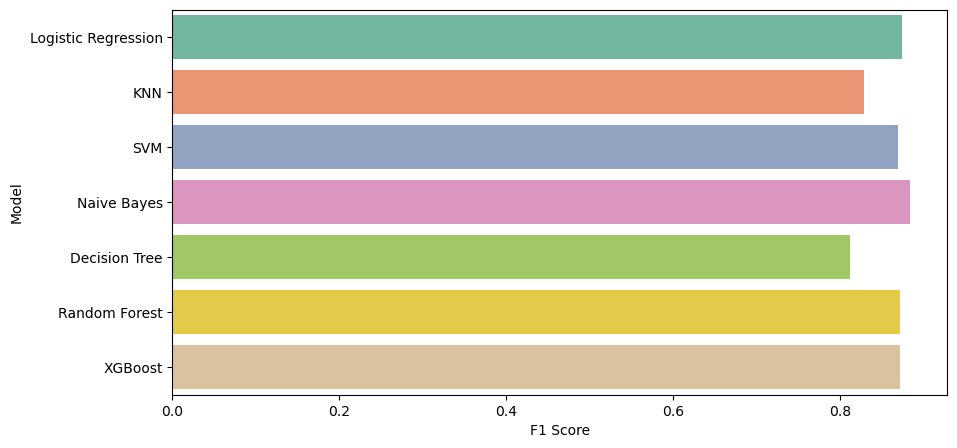

In [75]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="F1 Score",
    y="Model",
    data=results_df,
    palette="Set2"
)

plt.show()

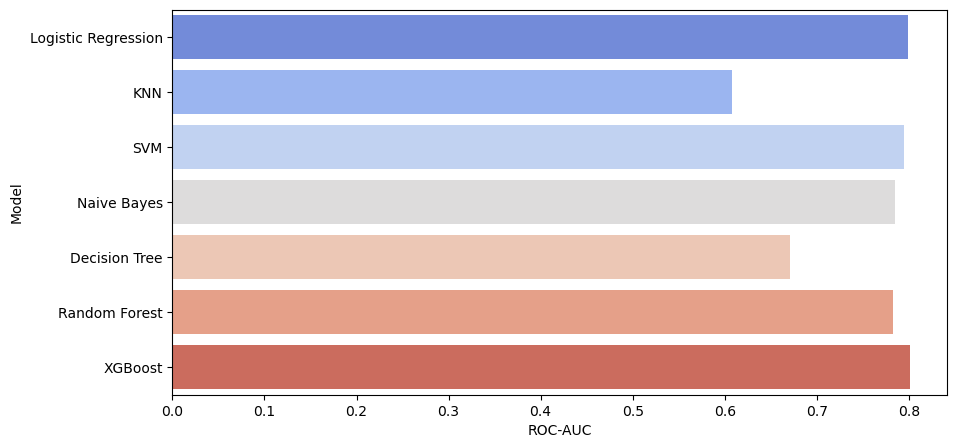

In [77]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="ROC-AUC",
    y="Model",
    data=results_df,
    palette="coolwarm"
)

plt.show()

In [79]:
rf = models["Random Forest"]

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
9,Credit_History,0.229825
14,LoanIncomeRatio,0.088185
12,Income_Loan_Ratio,0.084796
16,TotalIncome_Log,0.070249
5,ApplicantIncome,0.070104
11,TotalIncome,0.068697
15,ApplicantIncome_Log,0.065806
13,EMI,0.064684
17,LoanAmount_Log,0.057524
7,LoanAmount,0.052915


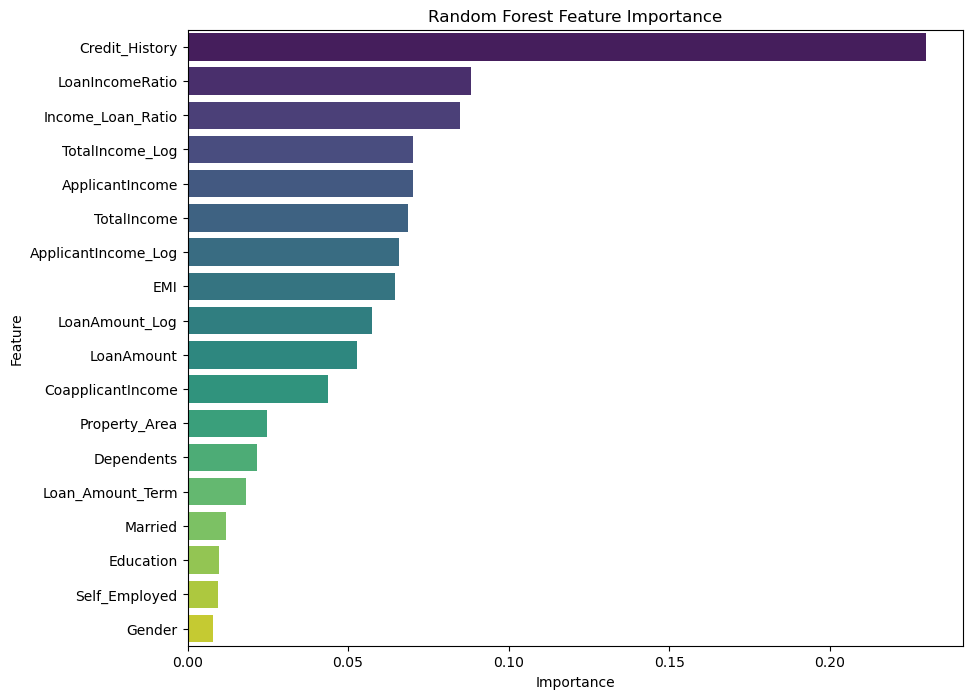

In [81]:
plt.figure(figsize=(10,8))

sns.barplot(

x="Importance",

y="Feature",

data=importance,

palette="viridis"

)

plt.title("Random Forest Feature Importance")

plt.show()

In [83]:
xgb = models["XGBoost"]

importance = pd.DataFrame({

    "Feature":X_train.columns,

    "Importance":xgb.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False

)

importance

,Feature,Importance
9,Credit_History,0.427856
8,Loan_Amount_Term,0.075385
14,LoanIncomeRatio,0.047196
7,LoanAmount,0.046359
12,Income_Loan_Ratio,0.046199
1,Married,0.043468
13,EMI,0.042753
4,Self_Employed,0.042406
5,ApplicantIncome,0.040854
11,TotalIncome,0.038773


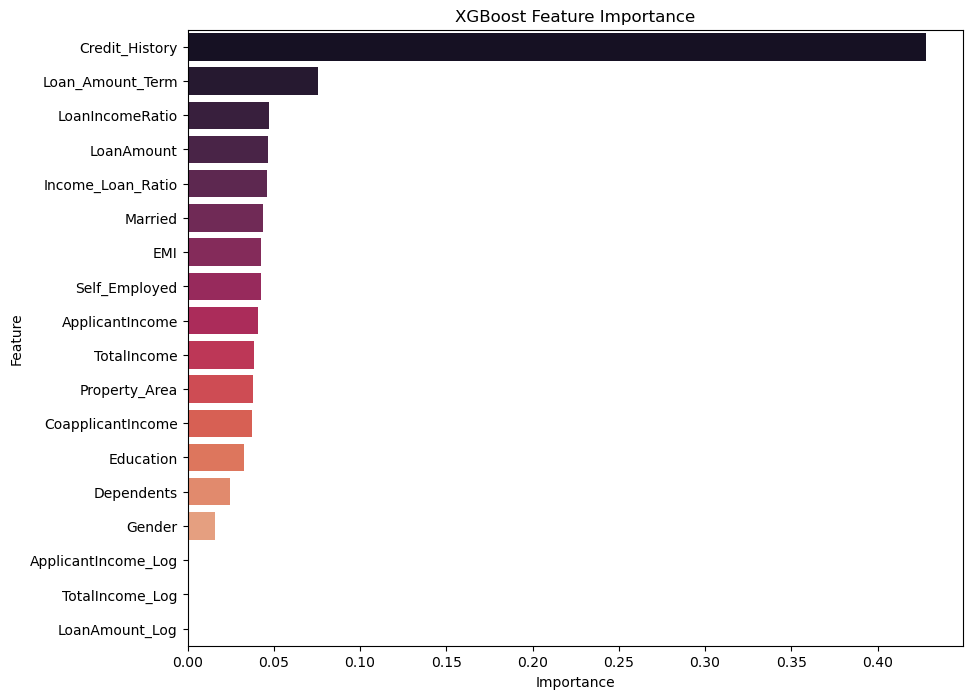

In [85]:
plt.figure(figsize=(10,8))

sns.barplot(

x="Importance",

y="Feature",

data=importance,

palette="rocket"

)

plt.title("XGBoost Feature Importance")

plt.show()

In [87]:
import joblib

In [89]:
best_model = models[best_model_name]

joblib.dump(

    best_model,

    "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/models/best_model.pkl"

)

print("Best model saved successfully!")

Best model saved successfully!


In [91]:
joblib.dump(

    scaler,

    "/Users/lingareddydhanushkumar/Desktop/Codex/ML/01_Loan_Approval_Prediction/models/scaler.pkl"

)

print("Scaler saved successfully!")

Scaler saved successfully!
